# Global Earthquakes

Reads from `quakes.sqlite`, populated by `fetch_quakes.py` (USGS FDSN catalog) and `fetch_significant.py` (NOAA NCEI fatality data via GitHub mirror + local recent supplement).

**Three coverage regimes** are mixed in this database on purpose:
- **M≥4.0 from 1965** (USGS): the WWSSN era. M4 detection is roughly comparable across this span.
- **M≥7.0 from 1900** (USGS): large quakes were detected globally even by sparse early-1900s networks.
- **Significant earthquakes 1900–today** (NOAA NCEI): events with notable deaths, damage, or magnitude.

Each plot is also saved to `figures/` as PNG. Re-execute the notebook to refresh them.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB = Path('quakes.sqlite')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

M4_COMPLETE_FROM = 1965
NETWORK_UPGRADE_YEAR = 2000
M7_COMPLETE_FROM = 1900
GREAT_QUAKE_MAG = 8.5

def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=140, bbox_inches='tight', facecolor='white')

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(
        'SELECT id, time_ms, mag, mag_type, lat, lon, depth_km, place '
        'FROM quakes ORDER BY time_ms',
        conn,
    )
    sig = pd.read_sql_query(
        'SELECT year, month, day, mag, lat, lon, location, deaths, damage_musd, source '
        'FROM significant_quakes ORDER BY year, month, day',
        conn,
    )
df['time'] = pd.to_datetime(df['time_ms'], unit='ms', utc=True)
df['year'] = df['time'].dt.year

latest = df['time'].max()
current_year = int(latest.year)
year_start = pd.Timestamp(f'{current_year}-01-01', tz='UTC')
year_end = pd.Timestamp(f'{current_year + 1}-01-01', tz='UTC')
year_fraction = (latest - year_start) / (year_end - year_start)
print(f'USGS catalog: {len(df):,} events, {df["time"].min():%Y-%m-%d} → {latest:%Y-%m-%d}')
print(f'NOAA significant: {len(sig):,} records  ({(sig["deaths"] > 0).sum():,} with recorded deaths)')
print(f'Current year ({current_year}) is {year_fraction:.1%} complete.')
df.head()

USGS catalog: 530,967 events, 1965-01-01 → 2026-06-03
NOAA significant: 3,523 records  (1,360 with recorded deaths)
Current year (2026) is 42.1% complete.


,id,time_ms,mag,mag_type,lat,lon,depth_km,place,time,year
0,ci3330737,-157737342220,4.46,ml,34.129333,-117.5090,3.310,"6km NW of Fontana, CA",1965-01-01 08:04:17.780000+00:00,1965
1,hv19650001,-157712534480,4.11,ml,19.814333,-155.3875,24.017,"24 km SW of Laup?hoehoe, Hawaii",1965-01-01 14:57:45.520000+00:00,1965
2,iscgem860696,-157688488640,5.64,mw,35.703000,4.3910,12.400,"13 km W of M’sila, Algeria",1965-01-01 21:38:31.360000+00:00,1965
3,iscgem860706,-157630541080,5.98,mw,19.246000,145.6160,131.600,"Maug Islands region, Northern Mariana Islands",1965-01-02 13:44:18.920000+00:00,1965
4,iscgem860737,-157465810500,5.76,mw,1.863000,127.3520,80.000,"74 km WNW of Tobelo, Indonesia",1965-01-04 11:29:49.500000+00:00,1965


## Magnitude vs Time

Each dot is one earthquake. M≥7.0 events highlighted as gold triangles. The grey shaded band on the right edge marks the partial current year.

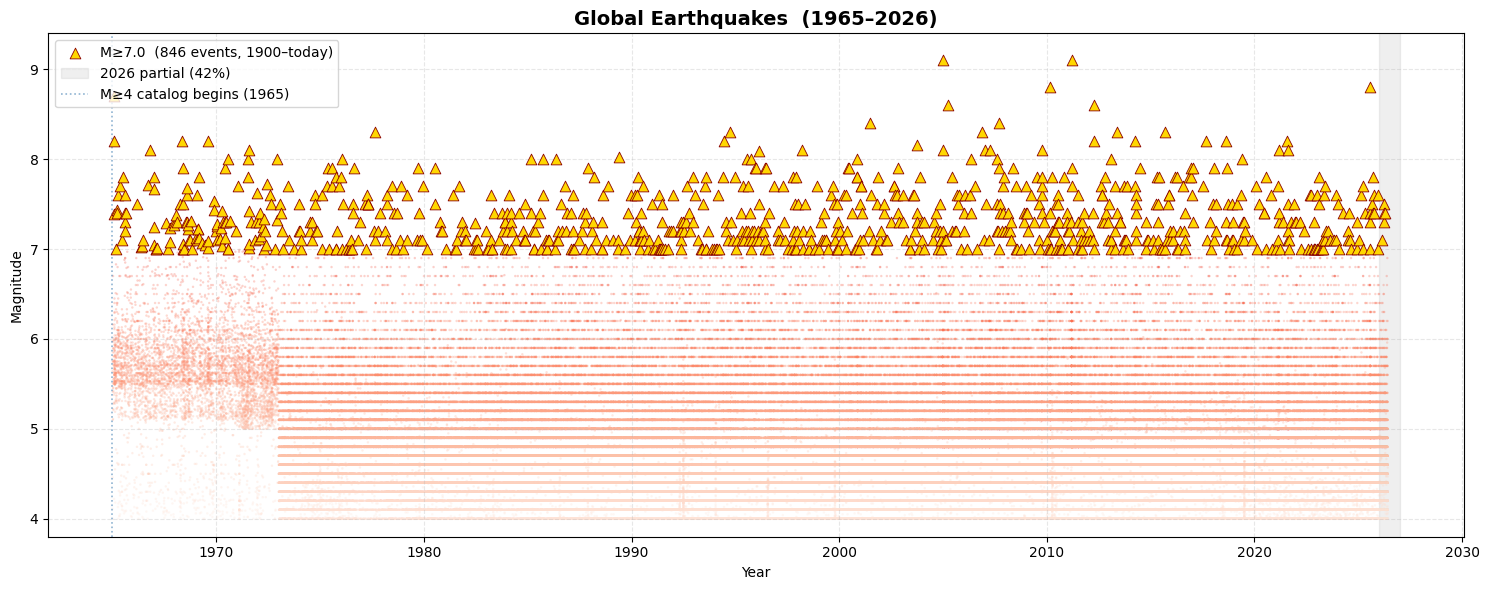

In [2]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(df['time'], df['mag'], c=df['mag'], cmap='Reds', alpha=0.25, s=3, linewidth=0)
major = df[df['mag'] >= 7.0]
ax.scatter(major['time'], major['mag'], c='gold', s=60, marker='^',
           edgecolors='darkred', linewidth=0.6, zorder=5,
           label=f'M≥7.0  ({len(major):,} events, 1900–today)')
ax.axvspan(year_start, year_end, color='grey', alpha=0.12, zorder=0,
           label=f'{current_year} partial ({year_fraction:.0%})')
ax.axvline(pd.Timestamp(f'{M4_COMPLETE_FROM}-01-01', tz='UTC'),
           color='steelblue', linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'M≥4 catalog begins ({M4_COMPLETE_FROM})')
ax.set_xlabel('Year'); ax.set_ylabel('Magnitude')
ax.set_title(f'Global Earthquakes  ({df["year"].min()}–{current_year})',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(3.8, df['mag'].max() + 0.3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
plt.tight_layout()
save_fig(fig, '01_magnitude_vs_time.png')
plt.show()

## Yearly Counts by Magnitude Band (M4 catalog only)

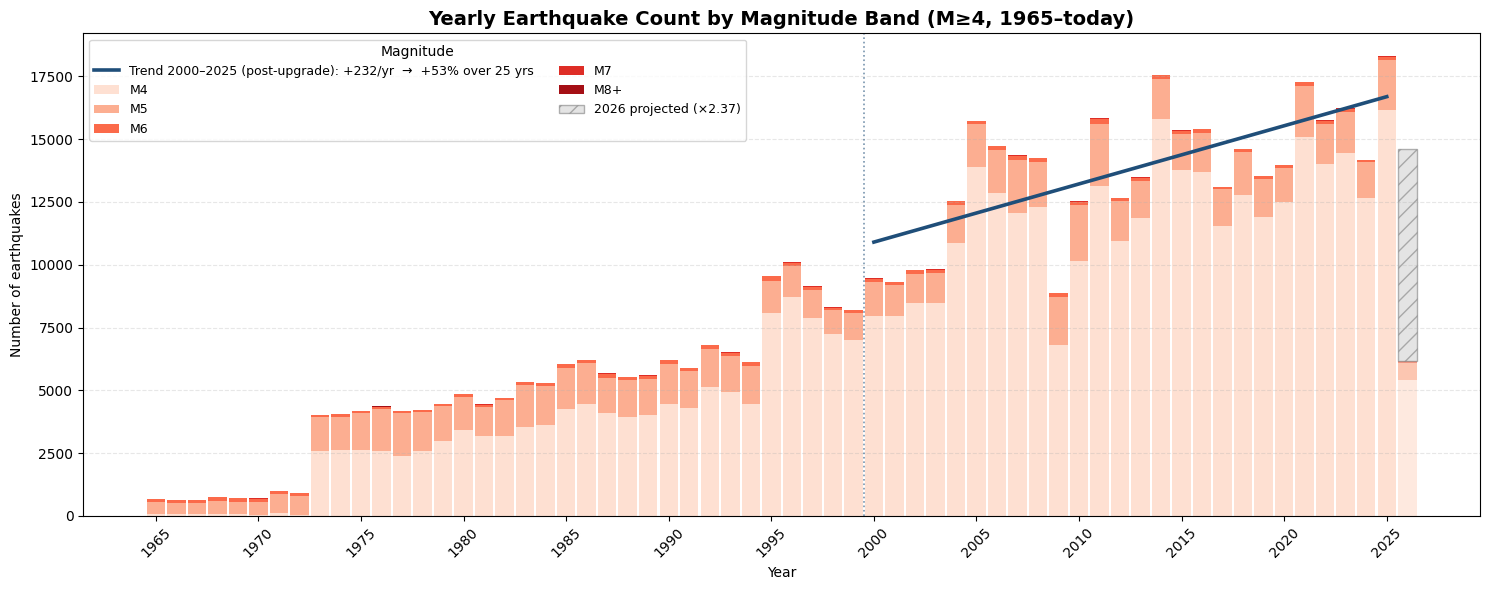

In [3]:
bands = [(4, 5, 'M4'), (5, 6, 'M5'), (6, 7, 'M6'), (7, 8, 'M7'), (8, 11, 'M8+')]
band_colors = ['#fee0d2', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

m4_era = df[df['year'] >= M4_COMPLETE_FROM]
by_year = pd.DataFrame({'year': sorted(m4_era['year'].unique())}).set_index('year')
for lo, hi, label in bands:
    sel = m4_era[(m4_era['mag'] >= lo) & (m4_era['mag'] < hi)]
    by_year[label] = sel.groupby('year').size()
by_year = by_year.fillna(0).astype(int)
complete_years = by_year.loc[by_year.index < current_year]
partial_row = by_year.loc[[current_year]] if current_year in by_year.index else None

fig, ax = plt.subplots(figsize=(15, 6))
year_to_x = {y: i for i, y in enumerate(by_year.index)}
bottom = np.zeros(len(complete_years))
for (lo, hi, label), color in zip(bands, band_colors):
    vals = complete_years[label].to_numpy()
    ax.bar([year_to_x[y] for y in complete_years.index], vals, bottom=bottom,
           color=color, width=0.9, label=label)
    bottom += vals
if partial_row is not None and year_fraction > 0:
    px = year_to_x[current_year]
    actual_total = int(partial_row.sum(axis=1).iloc[0])
    projected_total = actual_total / year_fraction
    bottom_p = 0.0
    for (lo, hi, label), color in zip(bands, band_colors):
        v = int(partial_row[label].iloc[0])
        ax.bar(px, v, bottom=bottom_p, color=color, width=0.9, alpha=0.7)
        bottom_p += v
    ax.bar(px, projected_total - actual_total, bottom=actual_total, color='lightgrey',
           width=0.9, alpha=0.6, hatch='//', edgecolor='grey',
           label=f'{current_year} projected (×{1/year_fraction:.2f})')
modern = complete_years.loc[complete_years.index >= NETWORK_UPGRADE_YEAR]
if len(modern) >= 5:
    m_yrs = modern.index.to_numpy()
    m_totals = modern.sum(axis=1).to_numpy()
    slope_m, intercept_m = np.polyfit(m_yrs, m_totals, 1)
    trend_m = slope_m * m_yrs + intercept_m
    n_yrs_m = m_yrs[-1] - m_yrs[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot([year_to_x[y] for y in m_yrs], trend_m, color='#1f4e79',
            linewidth=2.6,
            label=(f'Trend {m_yrs[0]}–{m_yrs[-1]} (post-upgrade): '
                   f'{slope_m:+.0f}/yr  →  {pct_m:+.0f}% over {n_yrs_m} yrs'))
if NETWORK_UPGRADE_YEAR in year_to_x:
    ax.axvline(year_to_x[NETWORK_UPGRADE_YEAR] - 0.5, color='#1f4e79',
               linestyle=':', linewidth=1.2, alpha=0.6)
ax.set_xlabel('Year'); ax.set_ylabel('Number of earthquakes')
ax.set_title('Yearly Earthquake Count by Magnitude Band (M≥4, 1965–today)',
             fontsize=14, fontweight='bold')
ax.legend(title='Magnitude', loc='upper left', ncol=2, fontsize=9)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
xpos = np.arange(len(by_year))
ax.set_xticks(xpos[::5])
ax.set_xticklabels(by_year.index[::5], rotation=45)
plt.tight_layout()
save_fig(fig, '02_yearly_by_band.png')
plt.show()

## M≥7.0 Yearly Counts — the detection-bias control (1900 → today)

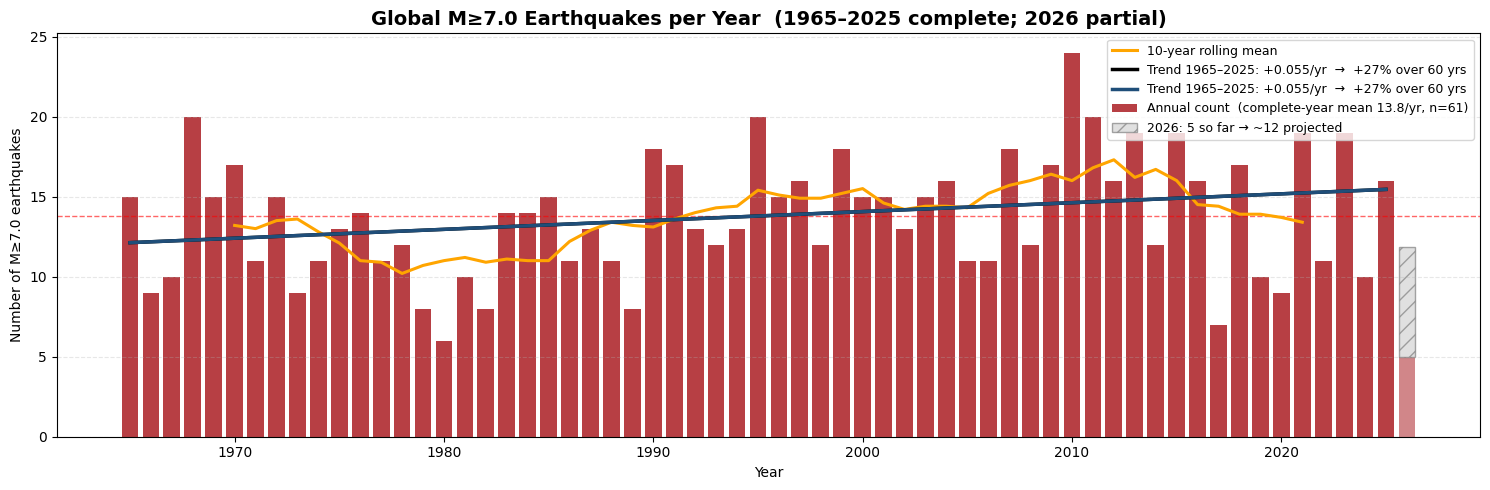

In [4]:
big = df[df['mag'] >= 7.0]
yearly_all = big.groupby('year').size()
yearly_all = yearly_all.reindex(range(yearly_all.index.min(), yearly_all.index.max() + 1), fill_value=0)
yearly = yearly_all[yearly_all.index < current_year]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(yearly.index, yearly.values, color='#a50f15', alpha=0.8,
       label=f'Annual count  (complete-year mean {yearly.mean():.1f}/yr, n={len(yearly)})')
if current_year in yearly_all.index and year_fraction > 0:
    actual7 = int(yearly_all.loc[current_year])
    projected7 = actual7 / year_fraction
    ax.bar(current_year, actual7, color='#a50f15', alpha=0.5)
    ax.bar(current_year, projected7 - actual7, bottom=actual7,
           color='lightgrey', alpha=0.7, hatch='//', edgecolor='grey',
           label=f'{current_year}: {actual7} so far → ~{projected7:.0f} projected')
ax.axhline(yearly.mean(), color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.plot(yearly.index, yearly.rolling(10, center=True).mean(),
        color='orange', linewidth=2.2, label='10-year rolling mean')
yi_long = yearly.index.to_numpy()
yv_long = yearly.values
slope_long, intercept_long = np.polyfit(yi_long, yv_long, 1)
trend_long = slope_long * yi_long + intercept_long
n_long = yi_long[-1] - yi_long[0]
pct_long = (trend_long[-1] - trend_long[0]) / trend_long[0] * 100
ax.plot(yi_long, trend_long, color='black', linewidth=2.5,
        label=f'Trend {yi_long[0]}–{yi_long[-1]}: {slope_long:+.3f}/yr  →  {pct_long:+.0f}% over {n_long} yrs')
yearly_modern = yearly[yearly.index >= M4_COMPLETE_FROM]
if len(yearly_modern) >= 5:
    yi_m = yearly_modern.index.to_numpy()
    yv_m = yearly_modern.values
    slope_m, intercept_m = np.polyfit(yi_m, yv_m, 1)
    trend_m = slope_m * yi_m + intercept_m
    n_m = yi_m[-1] - yi_m[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot(yi_m, trend_m, color='#1f4e79', linewidth=2.5,
            label=f'Trend {yi_m[0]}–{yi_m[-1]}: {slope_m:+.3f}/yr  →  {pct_m:+.0f}% over {n_m} yrs')
ax.set_xlabel('Year'); ax.set_ylabel('Number of M≥7.0 earthquakes')
ax.set_title(f'Global M≥7.0 Earthquakes per Year  ({yi_long[0]}–{yi_long[-1]} complete; {current_year} partial)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_fig(fig, '03_m7_yearly.png')
plt.show()

## M≥7.0 Trailing 12-Month Count

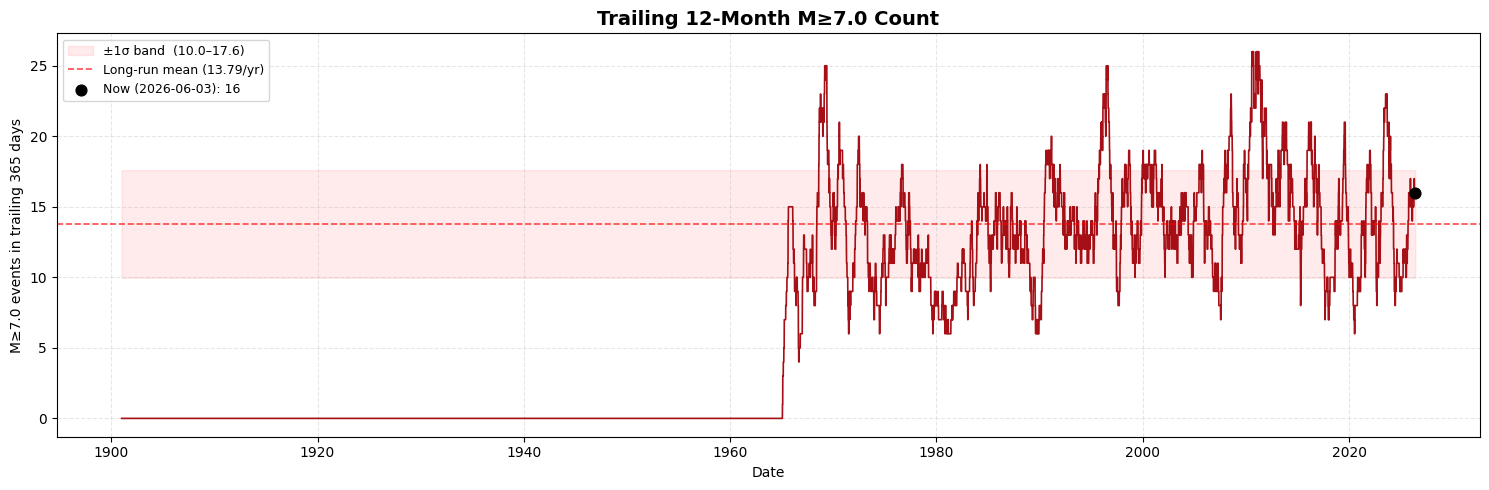

In [5]:
m7 = df[df['mag'] >= 7.0].copy()
m7['date'] = m7['time'].dt.normalize()
start = pd.Timestamp(f'{M7_COMPLETE_FROM}-01-01', tz='UTC')
end = latest.normalize()
daily_idx = pd.date_range(start, end, freq='D', tz='UTC')
daily = pd.Series(0, index=daily_idx, dtype=int)
per_day = m7.groupby('date').size()
daily.loc[per_day.index.intersection(daily.index)] = per_day.loc[per_day.index.intersection(daily.index)].values
trailing = daily.rolling('365D').sum()
trailing_valid = trailing[trailing.index >= start + pd.Timedelta(days=365)]
yearly_mean = yearly.mean()
yearly_std = yearly.std()
current_t12 = trailing_valid.iloc[-1]

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(trailing_valid.index,
                yearly_mean - yearly_std, yearly_mean + yearly_std,
                color='red', alpha=0.08, label=f'±1σ band  ({yearly_mean - yearly_std:.1f}–{yearly_mean + yearly_std:.1f})')
ax.plot(trailing_valid.index, trailing_valid.values, color='#a50f15', linewidth=1.2)
ax.axhline(yearly_mean, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Long-run mean ({yearly_mean:.2f}/yr)')
ax.scatter([latest], [current_t12], color='black', s=60, zorder=5,
           label=f'Now ({latest:%Y-%m-%d}): {current_t12:.0f}')
ax.set_xlabel('Date'); ax.set_ylabel('M≥7.0 events in trailing 365 days')
ax.set_title('Trailing 12-Month M≥7.0 Count', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
save_fig(fig, '04_m7_trailing_12mo.png')
plt.show()

## Decadal Intensity

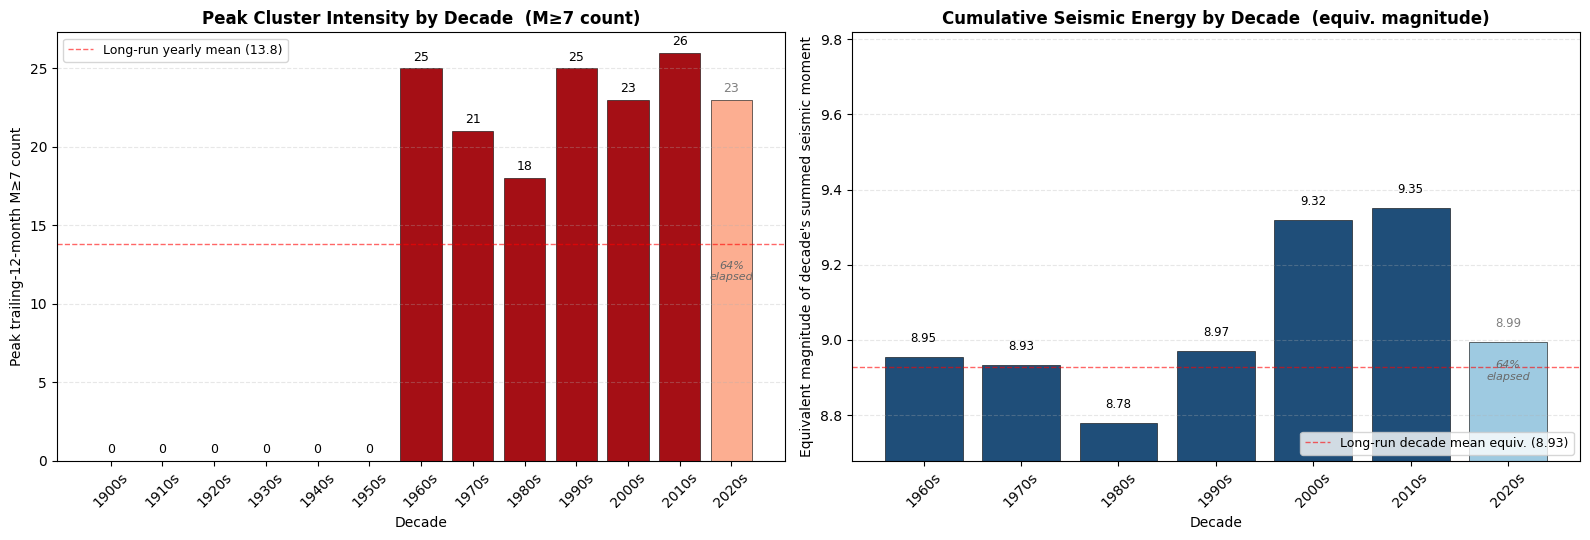

In [6]:
m7['decade'] = (m7['time'].dt.year // 10) * 10
trailing_decade = pd.Series((trailing_valid.index.year // 10) * 10, index=trailing_valid.index)
decade_peak = trailing_valid.groupby(trailing_decade).max()
m7['moment'] = 10 ** (1.5 * m7['mag'] + 9.1)
decade_moment = m7.groupby('decade')['moment'].sum()
decade_equiv_mag = (np.log10(decade_moment) - 9.1) / 1.5
current_decade = (current_year // 10) * 10
decade_elapsed_years = (latest - pd.Timestamp(f'{current_decade}-01-01', tz='UTC')).days / 365.25
decade_fraction = decade_elapsed_years / 10

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
decades = decade_peak.index.to_numpy()
is_partial = decades == current_decade
bar_colors = ['#a50f15' if not p else '#fcae91' for p in is_partial]
ax1.bar(decades, decade_peak.values, width=8, color=bar_colors, edgecolor='black', linewidth=0.4)
for d, v, p in zip(decades, decade_peak.values, is_partial):
    ax1.text(d, v + 0.5, f'{int(v)}', ha='center', fontsize=9, color='grey' if p else 'black')
ax1.axhline(yearly_mean, color='red', linestyle='--', linewidth=1, alpha=0.6,
            label=f'Long-run yearly mean ({yearly_mean:.1f})')
ax1.set_xlabel('Decade'); ax1.set_ylabel('Peak trailing-12-month M≥7 count')
ax1.set_title('Peak Cluster Intensity by Decade  (M≥7 count)', fontsize=12, fontweight='bold')
ax1.set_xticks(decades)
ax1.set_xticklabels([f"{d}s" for d in decades], rotation=45)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
if current_decade in decades:
    ax1.text(current_decade, decade_peak.loc[current_decade] / 2,
             f'{decade_fraction:.0%}\nelapsed', ha='center', fontsize=8,
             color='dimgrey', style='italic')
ax1.legend(loc='upper left', fontsize=9)

edecades = decade_equiv_mag.index.to_numpy()
eis_partial = edecades == current_decade
ebar_colors = ['#1f4e79' if not p else '#9ecae1' for p in eis_partial]
ax2.bar(edecades, decade_equiv_mag.values, width=8, color=ebar_colors, edgecolor='black', linewidth=0.4)
for d, v, p in zip(edecades, decade_equiv_mag.values, eis_partial):
    ax2.text(d, v + 0.04, f'{v:.2f}', ha='center', fontsize=8.5, color='grey' if p else 'black')
long_run_equiv = (np.log10(m7[m7['time'].dt.year < current_decade]['moment'].sum() /
                           ((current_decade - M7_COMPLETE_FROM) / 10)) - 9.1) / 1.5
ax2.axhline(long_run_equiv, color='red', linestyle='--', linewidth=1, alpha=0.6,
            label=f'Long-run decade mean equiv. ({long_run_equiv:.2f})')
ax2.set_xlabel('Decade'); ax2.set_ylabel('Equivalent magnitude of decade\'s summed seismic moment')
ax2.set_title('Cumulative Seismic Energy by Decade  (equiv. magnitude)', fontsize=12, fontweight='bold')
ax2.set_xticks(edecades)
ax2.set_xticklabels([f"{d}s" for d in edecades], rotation=45)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(bottom=max(8.5, decade_equiv_mag.min() - 0.1))
if current_decade in edecades:
    ax2.text(current_decade, decade_equiv_mag.loc[current_decade] - 0.1,
             f'{decade_fraction:.0%}\nelapsed', ha='center', fontsize=8, color='dimgrey', style='italic')
ax2.legend(loc='lower right', fontsize=9)
plt.tight_layout()
save_fig(fig, '05_decadal_intensity.png')
plt.show()

## Great Quake Timing

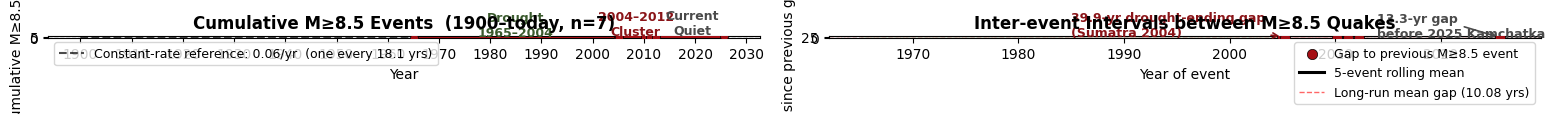

In [7]:
great = df[df['mag'] >= GREAT_QUAKE_MAG].sort_values('time').reset_index(drop=True)
great['interval_days'] = great['time'].diff().dt.total_seconds() / 86400
great['interval_years'] = great['interval_days'] / 365.25
n_great = len(great)
regimes = [
    (pd.Timestamp('1965-02-05', tz='UTC'), pd.Timestamp('2004-12-26', tz='UTC'),
     '#7fb069', 'Great Quake Drought\n(39.9 yrs, 0 events)'),
    (pd.Timestamp('2004-12-26', tz='UTC'), pd.Timestamp('2012-12-31', tz='UTC'),
     '#d62728', '2004–2012 Cluster\n(6 events in 8 yrs)'),
    (pd.Timestamp('2013-01-01', tz='UTC'), latest,
     '#a0a0a0', 'Current Quiet\n(1 event in 13 yrs)'),
]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for start_r, end_r, color, label in regimes:
    ax1.axvspan(start_r, end_r, color=color, alpha=0.18)
ax1.step(great['time'], np.arange(1, n_great + 1), where='post',
         color='#a50f15', linewidth=2.2, zorder=3)
ax1.scatter(great['time'], np.arange(1, n_great + 1),
            color='#a50f15', s=35, zorder=4, edgecolor='black', linewidth=0.5)
ref_start = pd.Timestamp(f'{M7_COMPLETE_FROM}-01-01', tz='UTC')
ref_end = latest
ref_span_yrs = (ref_end - ref_start).days / 365.25
ref_rate = n_great / ref_span_yrs
ax1.plot([ref_start, ref_end], [0, n_great], color='black', linestyle='--',
         linewidth=1.5, alpha=0.7, zorder=2,
         label=f'Constant-rate reference: {ref_rate:.2f}/yr  (one every {1/ref_rate:.1f} yrs)')
ax1.text(pd.Timestamp('1985-01-01', tz='UTC'), 6, 'Drought\n1965–2004',
         ha='center', fontsize=9, color='#3a5a2d', fontweight='bold')
ax1.text(pd.Timestamp('2008-06-01', tz='UTC'), 14, '2004–2012\nCluster',
         ha='center', fontsize=9, color='#8a1418', fontweight='bold')
ax1.text(pd.Timestamp('2019-06-01', tz='UTC'), 16.5, 'Current\nQuiet',
         ha='center', fontsize=9, color='#4a4a4a', fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel(f'Cumulative M≥{GREAT_QUAKE_MAG} events')
ax1.set_title(f'Cumulative M≥{GREAT_QUAKE_MAG} Events  ({M7_COMPLETE_FROM}–today, n={n_great})',
              fontsize=12, fontweight='bold')
ax1.xaxis.set_major_locator(mdates.YearLocator(10))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim(0, n_great + 1)
for start_r, end_r, color, label in regimes:
    ax2.axvspan(start_r, end_r, color=color, alpha=0.18)
intervals = great.dropna(subset=['interval_years']).copy()
ax2.scatter(intervals['time'], intervals['interval_years'],
            color='#a50f15', s=55, zorder=5, edgecolor='black', linewidth=0.5,
            label=f'Gap to previous M≥{GREAT_QUAKE_MAG} event')
rolling = intervals['interval_years'].rolling(5, center=True).mean()
ax2.plot(intervals['time'], rolling, color='black', linewidth=2.2,
         label='5-event rolling mean')
mean_gap = intervals['interval_years'].mean()
ax2.axhline(mean_gap, color='red', linestyle='--', linewidth=1, alpha=0.6,
            label=f'Long-run mean gap ({mean_gap:.2f} yrs)')
ax2.annotate('39.9-yr drought-ending gap\n(Sumatra 2004)',
             xy=(pd.Timestamp('2004-12-26', tz='UTC'), 39.9),
             xytext=(pd.Timestamp('1985-01-01', tz='UTC'), 32),
             fontsize=9, color='#8a1418', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#8a1418', lw=1.2))
ax2.annotate('13.3-yr gap\nbefore 2025 Kamchatka',
             xy=(pd.Timestamp('2025-07-29', tz='UTC'), 13.3),
             xytext=(pd.Timestamp('2014-01-01', tz='UTC'), 23),
             fontsize=9, color='#4a4a4a', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#4a4a4a', lw=1.2))
ax2.set_xlabel('Year of event'); ax2.set_ylabel('Years since previous great quake')
ax2.set_title(f'Inter-event Intervals between M≥{GREAT_QUAKE_MAG} Quakes',
              fontsize=12, fontweight='bold')
ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_fig(fig, '06_great_quake_timing.png')
plt.show()

## Human Cost — Earthquake Fatalities

**Important caveat: fatalities are not a measure of seismicity.** They measure where people happen to be living. A M6.0 under a megacity kills thousands; a M8.5 in the open ocean kills nobody. Trends in earthquake deaths over the 20th century are dominated by:
- Population growth and urbanization (~4× since 1900)
- Building codes (or their absence) in seismically active regions
- Warning systems and emergency response
- Where individual large events happen to strike

Read these as a *human-exposure* story, not a seismic one.

Data: NOAA NCEI Significant Earthquake Database (via GitHub mirror, through 2017) plus a hand-curated `recent_significant.tsv` for major 2018–today events sourced from USGS / Wikipedia. Replace with a fresh NOAA pull when their API is reachable.

### Annual Deaths and Cumulative Deaths

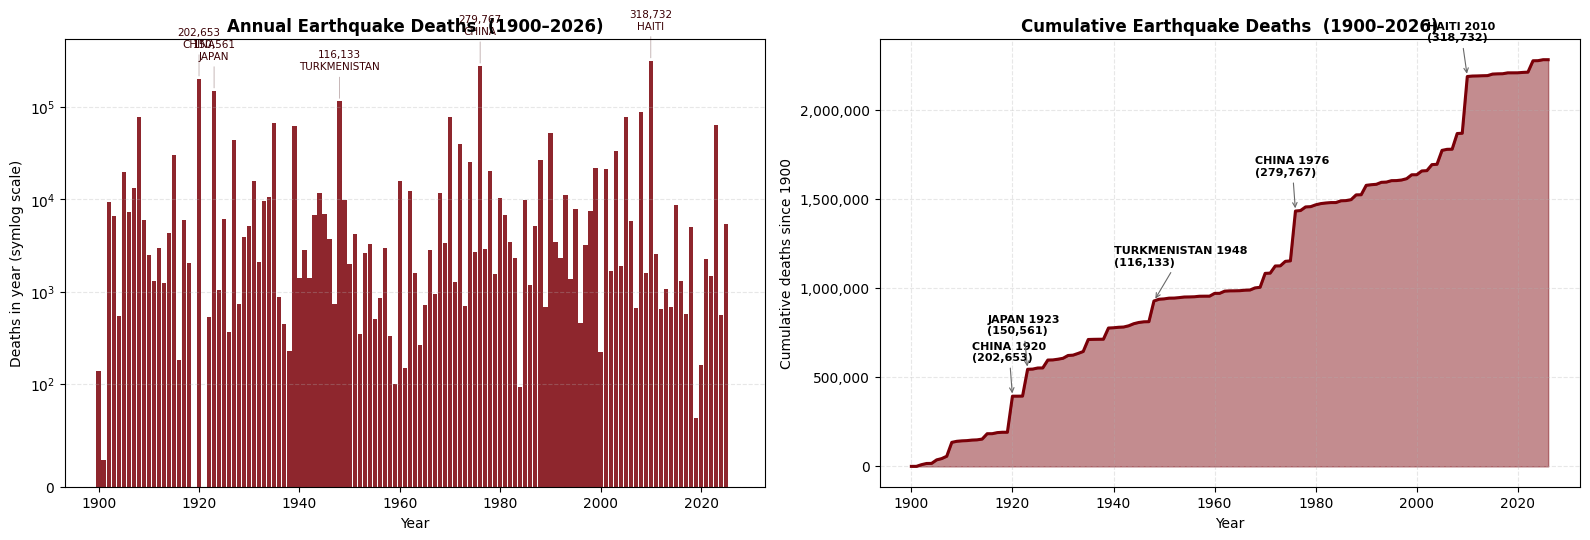

Total earthquake deaths recorded since 1900: 2,284,401
Years with no recorded deaths: 3

Deadliest single years:
  2010:   318,732 deaths   M7.0  HAITI:  PORT-AU-PRINCE
  1976:   279,767 deaths   M7.5  CHINA:  NE:  TANGSHAN
  1920:   202,653 deaths   M8.3  CHINA:  GANSU PROVINCE, SHANXI PROVINCE
  1923:   150,561 deaths   M7.9  JAPAN:  TOKYO, YOKOHAMA
  1948:   116,133 deaths   M7.3  TURKMENISTAN:  ASHKHABAD
  2008:    88,064 deaths   M7.9  CHINA:  SICHUAN PROVINCE
  1970:    78,260 deaths   M7.9  PERU: NORTHERN, PISCO, CHICLAYO
  2005:    78,195 deaths   M7.6  PAKISTAN:  MUZAFFARABAD, URI, ANANTNAG, BARAMULA
  1908:    78,000 deaths   M7.0  ITALY:  MESSINA, SICILY, CALABRIA
  1935:    67,440 deaths   M7.5  PAKISTAN:  QUETTA

Deaths per decade:
  1900s:     140,955
  1910s:      50,773
  1920s:     410,249
  1930s:     175,194
  1940s:     161,712
  1950s:      17,260
  1960s:      49,833
  1970s:     452,948
  1980s:      66,819
  1990s:     112,277
  2000s:     233,264
  2010s:     3

In [8]:
sig_with_deaths = sig[(sig['deaths'].notna()) & (sig['deaths'] > 0) & (sig['year'] >= 1900)].copy()
annual_deaths = sig_with_deaths.groupby('year')['deaths'].sum()
annual_deaths = annual_deaths.reindex(range(1900, current_year + 1), fill_value=0)
cumulative_deaths = annual_deaths.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel 1: Annual deaths (symlog scale handles zero years)
ax1.bar(annual_deaths.index, annual_deaths.values, color='#7a0008', alpha=0.85, width=0.85)
ax1.set_yscale('symlog', linthresh=100)
ax1.set_xlabel('Year'); ax1.set_ylabel('Deaths in year (symlog scale)')
ax1.set_title(f'Annual Earthquake Deaths  (1900–{current_year})',
              fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3, linestyle='--', which='both')

# Annotate the very deadliest years
for year, deaths in annual_deaths.nlargest(5).items():
    top_event = sig_with_deaths[sig_with_deaths['year'] == year].nlargest(1, 'deaths').iloc[0]
    place_short = top_event['location'].split(':')[0].split('(')[0].strip()[:18]
    ax1.annotate(f'{int(deaths):,}\n{place_short}',
                 xy=(year, deaths), xytext=(year, deaths * 2.2),
                 ha='center', fontsize=7.5, color='#3a0004',
                 arrowprops=dict(arrowstyle='-', color='#3a0004', lw=0.5, alpha=0.4))

# Panel 2: Cumulative deaths
ax2.fill_between(cumulative_deaths.index, 0, cumulative_deaths.values,
                 color='#7a0008', alpha=0.45)
ax2.plot(cumulative_deaths.index, cumulative_deaths.values,
         color='#7a0008', linewidth=2.2)
ax2.set_xlabel('Year'); ax2.set_ylabel('Cumulative deaths since 1900')
ax2.set_title(f'Cumulative Earthquake Deaths  (1900–{current_year})',
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Mark a few step events
for year, deaths in annual_deaths.nlargest(5).items():
    top_event = sig_with_deaths[sig_with_deaths['year'] == year].nlargest(1, 'deaths').iloc[0]
    place_short = top_event['location'].split(':')[0].split('(')[0].strip()[:20]
    cum_at_year = cumulative_deaths.loc[year]
    ax2.annotate(f'{place_short} {year}\n({int(deaths):,})',
                 xy=(year, cum_at_year), xytext=(year - 8, cum_at_year + 200000),
                 fontsize=8, color='black', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='dimgrey', lw=0.8))

plt.tight_layout()
save_fig(fig, '07_earthquake_deaths.png')
plt.show()

print(f'Total earthquake deaths recorded since 1900: {int(annual_deaths.sum()):,}')
print(f'Years with no recorded deaths: {(annual_deaths == 0).sum()}')
print()
print('Deadliest single years:')
for year, deaths in annual_deaths.nlargest(10).items():
    top_event = sig_with_deaths[sig_with_deaths['year'] == year].nlargest(1, 'deaths').iloc[0]
    print(f'  {year}:  {int(deaths):>8,} deaths   M{top_event["mag"] or 0:.1f}  {top_event["location"][:60]}')
print()
print('Deaths per decade:')
decade_deaths = annual_deaths.groupby((annual_deaths.index // 10) * 10).sum()
for dec, deaths in decade_deaths.items():
    partial = '  (partial)' if dec == current_decade else ''
    print(f'  {int(dec)}s:  {int(deaths):>10,}{partial}')

### Deaths vs Magnitude

If lethality were just about seismic energy, this scatter would be a clean upward trend — bigger quake, more deaths. It isn't. The vertical spread at any given magnitude is enormous: M7.0 events range from zero deaths (open ocean, low population) to over 300,000 (Haiti 2010, with poor building stock and a city of 3M directly above). This plot is the clearest evidence that fatalities are about *where* and *what's built there*, not the seismic event itself.

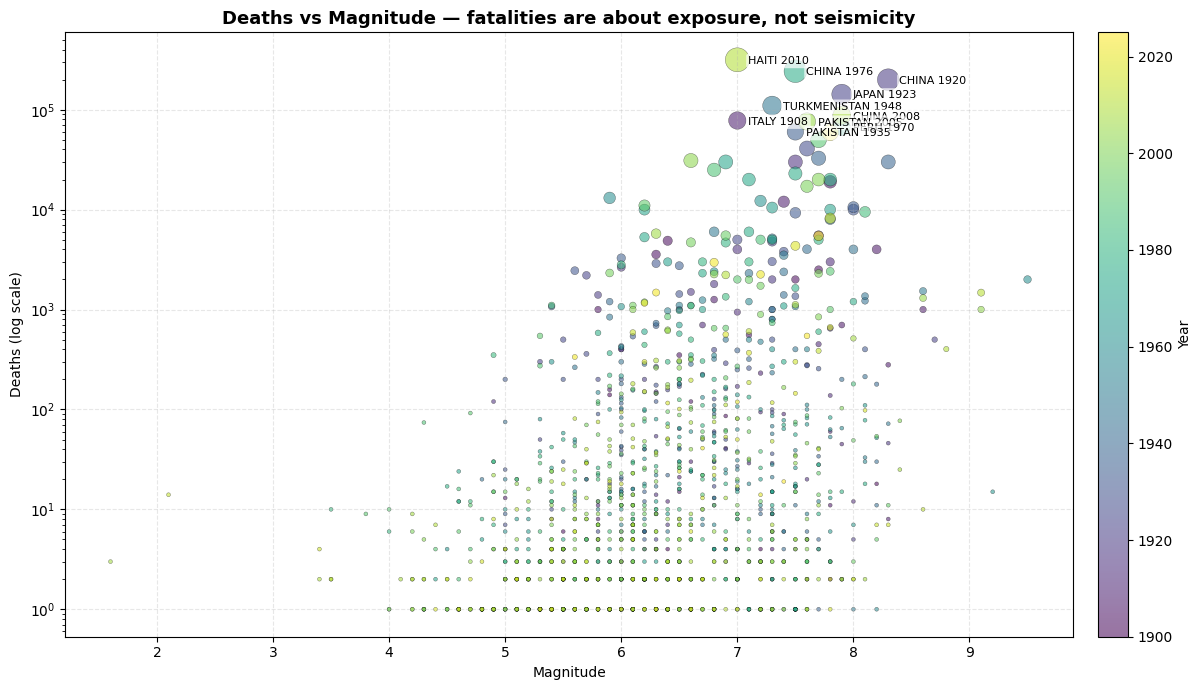

Sample: M7.0 ± 0.1 events with recorded deaths, illustrating the spread:
  M7.0  2010  deaths=316,000  HAITI:  PORT-AU-PRINCE
  M7.0  1908  deaths= 78,000  ITALY:  MESSINA, SICILY, CALABRIA
  M6.9  1972  deaths= 30,000  IRAN:  QIR,KARZIN, JAHROM, FIRUZABAD
  M7.1  1974  deaths= 20,000  CHINA:  YUNNAN AND SICHUAN PROVINCES, CHAO-T'UNG
  M7.1  1976  deaths=  6,000  INDONESIA:  NEW GUINEA:  IRIAN JAYA
  M6.9  1995  deaths=  5,502  JAPAN:  SW HONSHU:  KOBE, AWAJI-SHIMA, NISHINOMIYA
  M7.0  1925  deaths=  5,000  CHINA:  YUNNAN PROVINCE:  TALIFU
  M6.9  1980  deaths=  4,689  ITALY:   AVELLINO, POTENZA, CASERTA, NAPLES
  M7.0  1914  deaths=  4,000  TURKEY:  BURDUR, KILINC, KECIBORLU, ISPARTA
  M7.1  1981  deaths=  3,000  IRAN:  SE, KERMAN


In [9]:
scatter_data = sig[(sig['deaths'].notna()) & (sig['deaths'] > 0) & (sig['mag'].notna()) & (sig['year'] >= 1900)].copy()
fig, ax = plt.subplots(figsize=(13, 7))

sc = ax.scatter(scatter_data['mag'], scatter_data['deaths'],
                c=scatter_data['year'], cmap='viridis',
                s=np.clip(scatter_data['deaths'] ** 0.45, 8, 400),
                alpha=0.55, edgecolor='black', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('Magnitude'); ax.set_ylabel('Deaths (log scale)')
ax.set_title('Deaths vs Magnitude — fatalities are about exposure, not seismicity',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
cbar = plt.colorbar(sc, ax=ax, label='Year', pad=0.02)

# Annotate the outliers — where the magnitude is modest but deaths are very high
top_lethal = scatter_data.nlargest(10, 'deaths')
for _, row in top_lethal.iterrows():
    place = row['location'].split(':')[0].split('(')[0].strip()[:18]
    ax.annotate(f"{place} {int(row['year'])}",
                xy=(row['mag'], row['deaths']),
                xytext=(8, -3), textcoords='offset points',
                fontsize=8, color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
save_fig(fig, '08_deaths_vs_magnitude.png')
plt.show()

print('Sample: M7.0 ± 0.1 events with recorded deaths, illustrating the spread:')
m7_sample = scatter_data[(scatter_data['mag'] >= 6.9) & (scatter_data['mag'] <= 7.1)].nlargest(10, 'deaths')
for _, row in m7_sample.iterrows():
    print(f'  M{row["mag"]:.1f}  {int(row["year"])}  deaths={int(row["deaths"]):>7,}  {row["location"][:60]}')

## Magnitude Distribution (M≥4 catalog only)

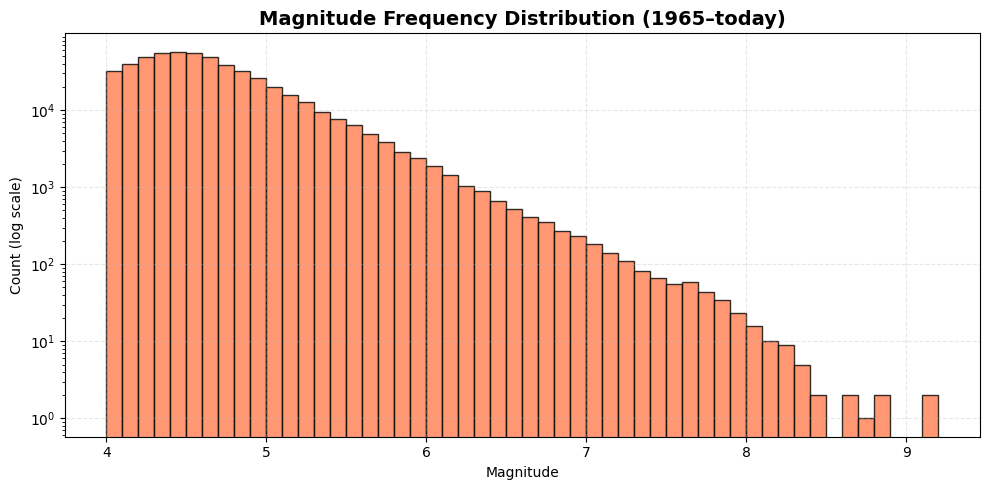

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(m4_era['mag'], bins=np.arange(4.0, m4_era['mag'].max() + 0.2, 0.1),
        color='coral', edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Magnitude'); ax.set_ylabel('Count (log scale)')
ax.set_title(f'Magnitude Frequency Distribution ({M4_COMPLETE_FROM}–today)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
save_fig(fig, '09_magnitude_distribution.png')
plt.show()

## Stats

In [11]:
complete_df = df[df['year'] < current_year]
m4_complete = complete_df[complete_df['year'] >= M4_COMPLETE_FROM]
n_m4_years = m4_complete['year'].nunique()
m7_complete = complete_df[complete_df['mag'] >= 7.0]

print(f'USGS catalog:')
print(f'  Total events:        {len(df):,}')
print(f'  M≥4 range:           {m4_complete["time"].min():%Y-%m-%d} → {m4_complete["time"].max():%Y-%m-%d}  ({n_m4_years} yrs)')
print(f'  M≥7 range:           {m7_complete["time"].min():%Y-%m-%d} → {m7_complete["time"].max():%Y-%m-%d}')
print(f'  Magnitude range:     {df["mag"].min():.1f} → {df["mag"].max():.1f}')
print()
print(f'NOAA significant earthquake database:')
print(f'  Total records:       {len(sig):,}')
print(f'  Records with deaths: {(sig["deaths"] > 0).sum():,}')
print(f'  Total deaths 1900+:  {int(sig[(sig["deaths"] > 0) & (sig["year"] >= 1900)]["deaths"].sum()):,}')
print()
print('Counts by magnitude band, M≥4 era:')
for lo, hi, label in bands:
    n = ((m4_complete['mag'] >= lo) & (m4_complete['mag'] < hi)).sum()
    print(f'  {label:5s}  {n:>9,}    ({n/n_m4_years:>7.1f}/yr)')
print()
print('Top 10 largest events (by magnitude):')
for _, row in df.nlargest(10, 'mag')[['time', 'mag', 'place']].iterrows():
    print(f'  {row["time"]:%Y-%m-%d}  M{row["mag"]:.1f}  {row["place"]}')
print()
print('Top 10 deadliest events (by recorded fatalities):')
top_deadly = sig[sig['deaths'].notna()].nlargest(10, 'deaths')
for _, row in top_deadly.iterrows():
    print(f'  {int(row["year"])}-{int(row["month"] or 0):02d}-{int(row["day"] or 0):02d}  '
          f'M{row["mag"] or 0:.1f}  deaths={int(row["deaths"]):>7,}  {row["location"][:55]}')

USGS catalog:
  Total events:        530,967
  M≥4 range:           1965-01-01 → 2025-12-31  (61 yrs)
  M≥7 range:           1965-01-24 → 2025-12-08
  Magnitude range:     3.4 → 9.1

NOAA significant earthquake database:
  Total records:       3,523
  Records with deaths: 1,360
  Total deaths 1900+:  2,284,401

Counts by magnitude band, M≥4 era:
  M4       430,940    ( 7064.6/yr)
  M5        85,390    ( 1399.8/yr)
  M6         7,639    (  125.2/yr)
  M7           792    (   13.0/yr)
  M8+           49    (    0.8/yr)

Top 10 largest events (by magnitude):
  2004-12-26  M9.1  2004 Sumatra - Andaman Islands Earthquake
  2011-03-11  M9.1  2011 Great Tohoku Earthquake, Japan
  2010-02-27  M8.8  2010 Maule, Chile Earthquake
  2025-07-29  M8.8  2025 Kamchatka Peninsula, Russia Earthquake
  1965-02-04  M8.7  1965 Western Aleutian Islands (Hawadax/Rat Islands) Earthquake
  2005-03-28  M8.6  78 km WSW of Singkil, Indonesia
  2012-04-11  M8.6  2012 Wharton Basin Earthquake
  2001-06-23  M8.4  6 